# CNN CIFAR-10 Classification

Nome: Gabriel Filipe da Silva Melo. Matrícula: 125.304-6

Nesse exercício a ideia é comparar uma CNN base com uma regularizada.

1. **Baseline CNN** — Sem Regularizaçao
2. **Regularized CNN** — SpatialDropout, Batch Normalization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, SpatialDropout2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

SEED = 42
np.random.seed(SEED)

I0000 00:00:1787441241.140270   51013 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787441241.140553   51013 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787441241.167304   51013 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787441241.829133   51013 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

### Load and Prepare the Data

In [2]:
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Labels — Train: {y_train.shape}, Test: {y_test.shape}")

Train: (50000, 32, 32, 3), Test: (10000, 32, 32, 3)
Labels — Train: (50000, 1), Test: (10000, 1)


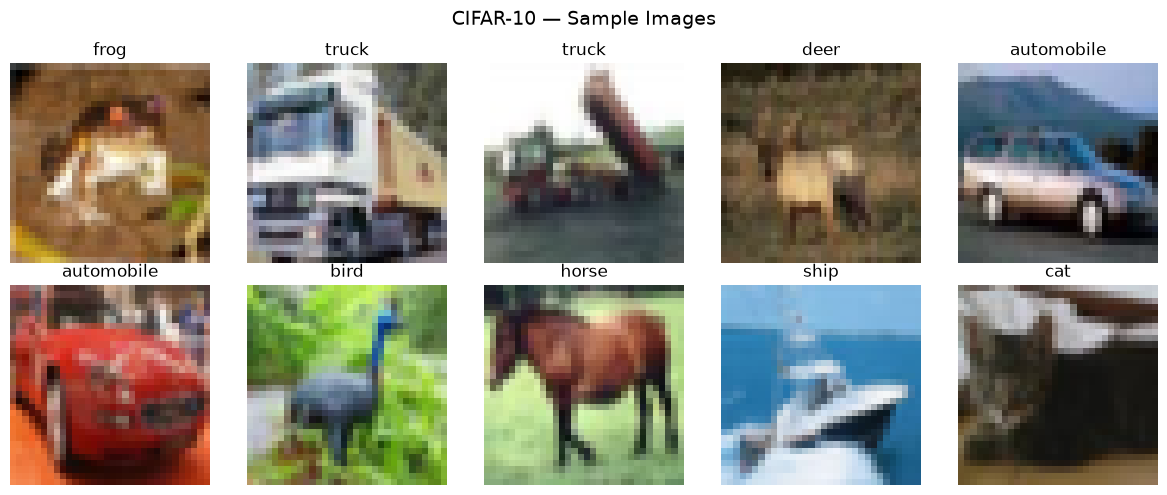

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]])
    ax.axis("off")
plt.suptitle("CIFAR-10 — Sample Images", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Normalizing (Similar to what was done with MNIST and EMNIST)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print(f"x_train: {x_train.shape}, y_train_cat: {y_train_cat.shape}")

x_train: (50000, 32, 32, 3), y_train_cat: (50000, 10)


## Baseline CNN (No Reg)

In [5]:
def build_baseline_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(256, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ])
    return model


model_baseline = build_baseline_cnn()
model_baseline.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_baseline.summary()

/home/melo/Projects/machine-learning/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787441250.576317   51013 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787441250.600676   51013 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 40
BATCH_SIZE = 2048

history_baseline = model_baseline.fit(
    x_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[],
    verbose=1,
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.4086 - loss: 1.6704 - val_accuracy: 0.4348 - val_loss: 1.5594
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.4548 - loss: 1.5290 - val_accuracy: 0.4670 - val_loss: 1.4842
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.4914 - loss: 1.4289 - val_accuracy: 0.5098 - val_loss: 1.3639
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 186ms/step - accuracy: 0.5211 - loss: 1.3464 - val_accuracy: 0.5382 - val_loss: 1.3032
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.5427 - loss: 1.2893 - val_accuracy: 0.5528 - val_loss: 1.2614
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.5578 - loss: 1.2593 - val_accuracy: 0.5760 - val_loss: 1.2309
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.5801 - loss: 1.1958 - val_accuracy: 0.5826 - val_loss: 1.1968
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 183ms/step - accuracy: 0.5921 - loss: 1.1680 - val_accuracy: 0.

### CNN Regularizada (SpatialDropout + BatchNorm)

In [8]:
def build_regularized_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        SpatialDropout2D(0.25),

        Flatten(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ])
    return model


model_reg = build_regularized_cnn()
model_reg.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 16, 16, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 8, 8, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 4, 4, 128)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
history_reg = model_reg.fit(
    x_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[],
    verbose=1,
)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.3024 - loss: 2.3940 - val_accuracy: 0.0992 - val_loss: 2.3276
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 448ms/step - accuracy: 0.3980 - loss: 1.8120 - val_accuracy: 0.0964 - val_loss: 2.5772
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 444ms/step - accuracy: 0.4438 - loss: 1.6124 - val_accuracy: 0.0950 - val_loss: 2.9483
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 446ms/step - accuracy: 0.4840 - loss: 1.4907 - val_accuracy: 0.0958 - val_loss: 3.1057
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.5091 - loss: 1.3999 - val_accuracy: 0.0962 - val_loss: 2.9602
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 445ms/step - accuracy: 0.5388 - loss: 1.3092 - val_accuracy: 0.0952 - val_loss: 3.2011
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 446ms/step - accuracy: 0.5611 - loss: 1.2441 - val_accuracy: 0.0978 - val_loss: 2.9641
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 447ms/step - accuracy: 0.5804 - loss: 1.1918 - val_accu

### Training Curves Comparison

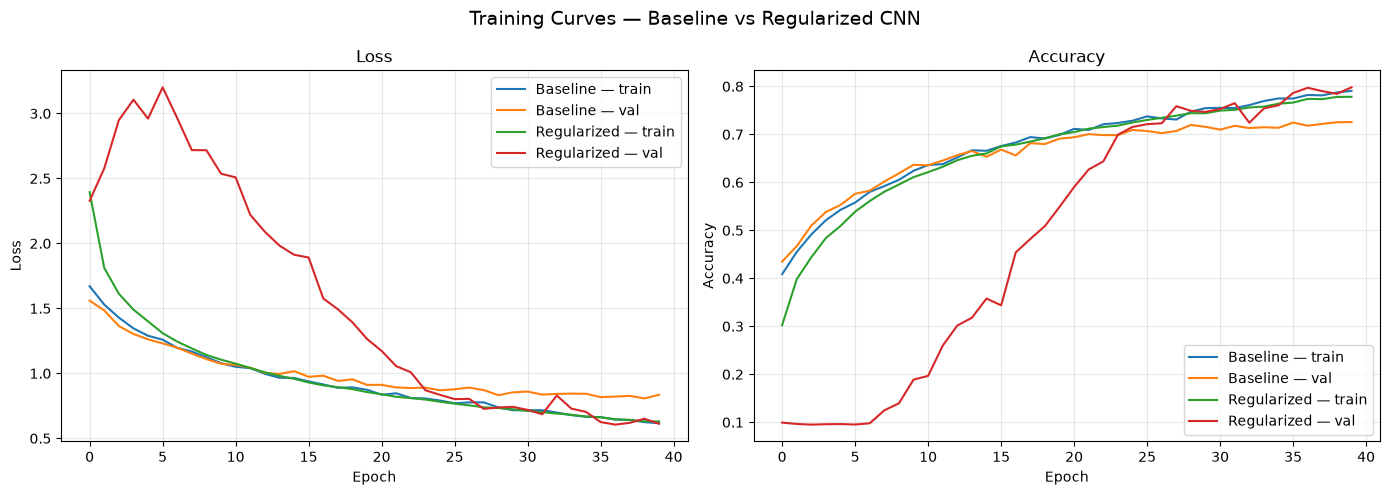

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss ----
axes[0].plot(history_baseline.history["loss"], label="Baseline — train")
axes[0].plot(history_baseline.history["val_loss"], label="Baseline — val")
axes[0].plot(history_reg.history["loss"], label="Regularized — train")
axes[0].plot(history_reg.history["val_loss"], label="Regularized — val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Accuracy ----
axes[1].plot(history_baseline.history["accuracy"], label="Baseline — train")
axes[1].plot(history_baseline.history["val_accuracy"], label="Baseline — val")
axes[1].plot(history_reg.history["accuracy"], label="Regularized — train")
axes[1].plot(history_reg.history["val_accuracy"], label="Regularized — val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Curves — Baseline vs Regularized CNN", fontsize=14)
plt.tight_layout()
plt.show()

### Evaluation on Test Set

In [11]:
loss_base, acc_base = model_baseline.evaluate(x_test, y_test_cat, verbose=0)
loss_reg, acc_reg   = model_reg.evaluate(x_test, y_test_cat, verbose=0)

print(f"{'Model':<20} {'Test Loss':>10} {'Test Acc':>10}")
print("-" * 42)
print(f"{'Baseline CNN':<20} {loss_base:>10.4f} {acc_base:>10.4f}")
print(f"{'Regularized CNN':<20} {loss_reg:>10.4f} {acc_reg:>10.4f}")

Model                 Test Loss   Test Acc
------------------------------------------
Baseline CNN             0.8691     0.7030
Regularized CNN          0.6539     0.7827


### Overfitting Gap Analysis

In [12]:
gap_base = max(history_baseline.history["accuracy"]) - max(history_baseline.history["val_accuracy"])
gap_reg  = max(history_reg.history["accuracy"]) - max(history_reg.history["val_accuracy"])

print(f"{'Model':<20} {'Train-Val Acc Gap':>18}")
print("-" * 40)
print(f"{'Baseline CNN':<20} {gap_base:>18.4f}")
print(f"{'Regularized CNN':<20} {gap_reg:>18.4f}")

Model                 Train-Val Acc Gap
----------------------------------------
Baseline CNN                     0.0651
Regularized CNN                 -0.0198


In [13]:
y_pred_base = np.argmax(model_baseline.predict(x_test), axis=1)
y_pred_reg  = np.argmax(model_reg.predict(x_test), axis=1)
y_true      = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [14]:
print("Classification Report — Baseline CNN")
print("=" * 55)
print(classification_report(y_true, y_pred_base, target_names=CLASS_NAMES))

print("Classification Report — Regularized CNN")
print("=" * 55)
print(classification_report(y_true, y_pred_reg, target_names=CLASS_NAMES))

Classification Report — Baseline CNN
              precision    recall  f1-score   support

    airplane       0.73      0.78      0.76      1000
  automobile       0.75      0.86      0.80      1000
        bird       0.54      0.70      0.61      1000
         cat       0.56      0.47      0.51      1000
        deer       0.78      0.52      0.63      1000
         dog       0.63      0.61      0.62      1000
        frog       0.69      0.82      0.75      1000
       horse       0.80      0.72      0.76      1000
        ship       0.88      0.75      0.81      1000
       truck       0.75      0.79      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000

Classification Report — Regularized CNN
              precision    recall  f1-score   support

    airplane       0.83      0.81      0.82      1000
  automobile       0.90      0.88      0.89      1000
 

### Confusion Matrices

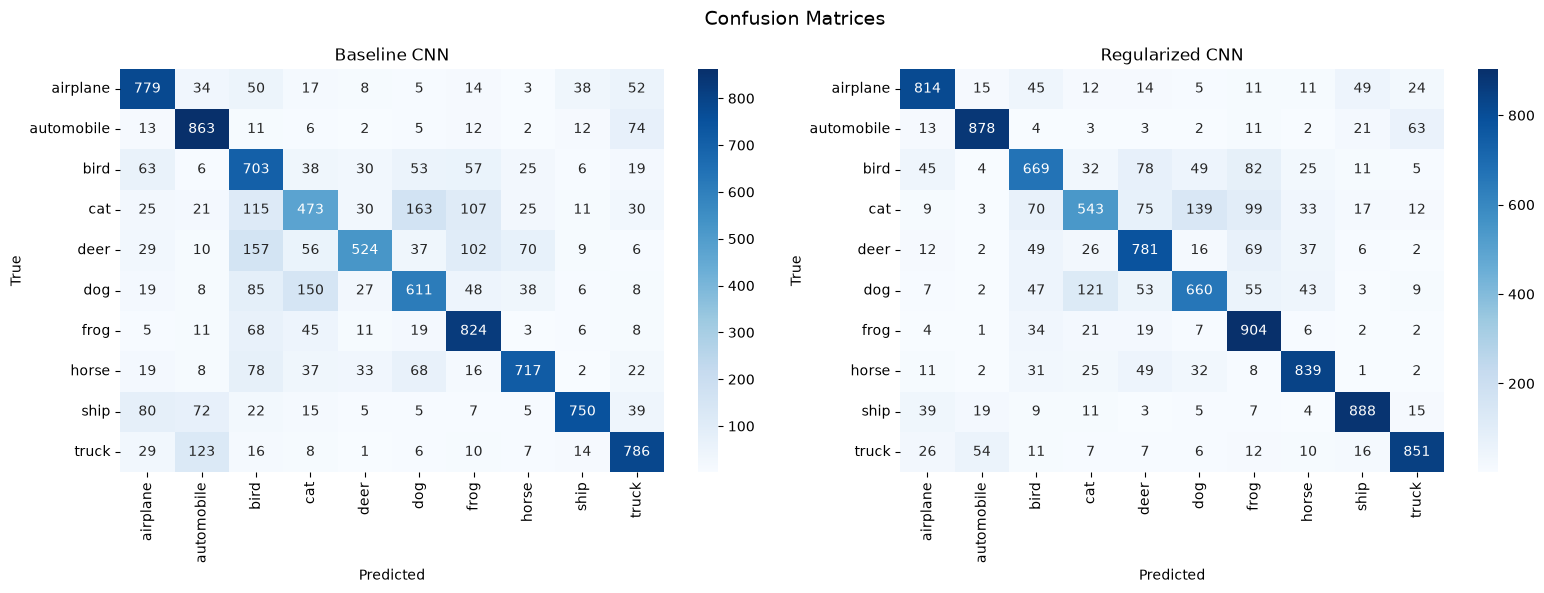

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in [
    (axes[0], y_pred_base, "Baseline CNN"),
    (axes[1], y_pred_reg,  "Regularized CNN"),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

### Visualizing Predictions

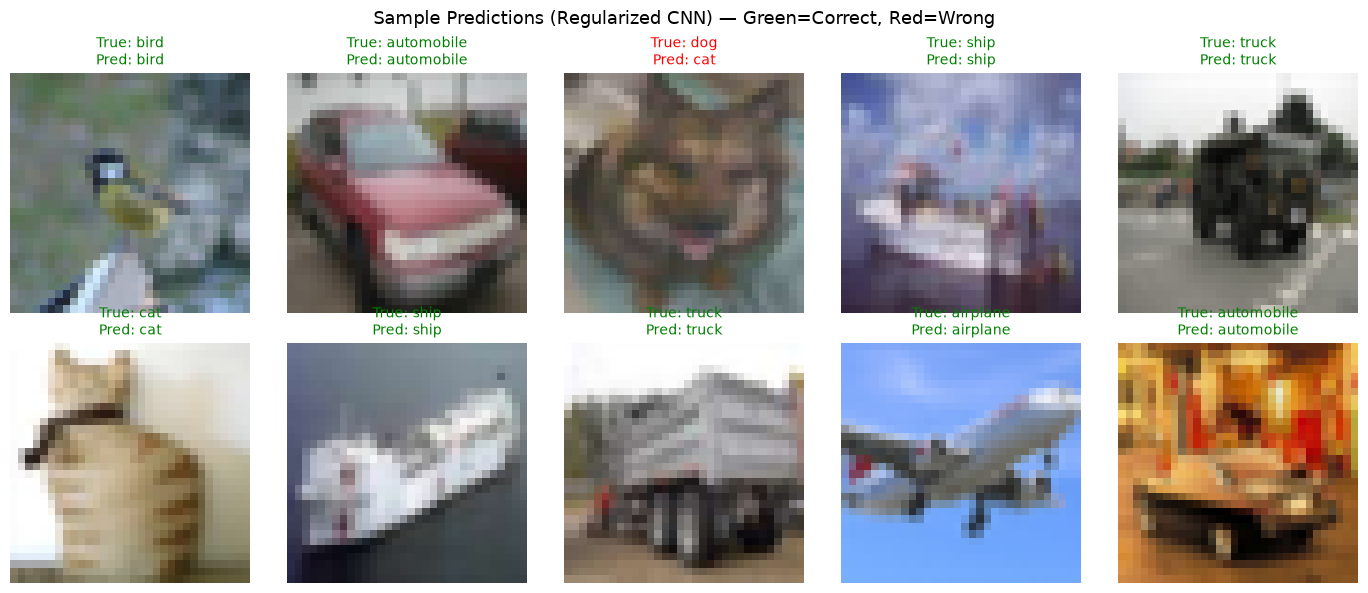

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

indices = np.random.choice(len(x_test), 10, replace=False)

for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(x_test[idx])
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred_reg[idx]]
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Predictions (Regularized CNN) — Green=Correct, Red=Wrong", fontsize=13)
plt.tight_layout()
plt.show()